# Image processing notebook: From overlap corrected to transmission 

### 00 - sa from exp 1XX

### Import libraries
Import all the required libraries

In [1]:
import sys
#sys.path.append(r'..\framework')
sys.path.append(r'..\proc_functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
%matplotlib inline

### Select directories
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\testing_overlap_corrected_sa\exp1XX"

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_new_framweork_results\exp1XX_SA_avg"

### Select working folders

In [4]:
stack_dict = prep_stack_dict(src_dir)
for key in stack_dict.keys():
    print(key)

00_ob
01_so_ref
02_sa
02_sa_2_2
03_ob_end


## Reference images test processing

### Select the reference folder to apply the processing and have it ready for subsequent experiments

In [5]:
ref_folder = ['01_so_ref']

### We use testing mode to reduce the total number of acquisitions to a minumum given. This allows to test and have a glance of the final image

In [6]:
ref_test_dict, weights_DataFrame = testing_mode_step (src_dir, proc_folder = ref_folder, keep_acq_numb = 4)

Reading Images: 100%|████████████████████████████| 3/3 [00:05<00:00,  1.74s/it]


In [7]:
test = ref_test_dict['01_so_ref'][0][100]
#show_img(test[0])
#test[1]

### Give parameters according to the pre processing required. (Explain what pre-processing means)

In [8]:
pre_proc_seq = [outlier_removal, stack_averaging]
pre_proc_param = dict (threshold = 0)

### Do the pre processing step (per acquisition folder it takes ~26 seconds, please be patient)

In [9]:
ref_test_dict = pre_processing_step (ref_test_dict, pre_proc_seq, pre_proc_param)

Processing Filetring : 100%|█████████████████████| 4/4 [01:45<00:00, 26.34s/it]


In [10]:
test = ref_test_dict['01_so_ref'][0][10]
#show_img(test[0])
#test[1]

### Give the processing steps and the variables needed for all the steps. For the reference, we separate the processing in 2 steps, because we require a corrected reference image for the TFC correction

In [11]:
proc_seq = ['scrubbing_correction_dict', 'SBKG_correction_dict']

In [12]:
BB_mask = get_img(src_dir + '/bb_mask_ref_full.fits')

In [13]:
list_proc_param = ['weights_DataFrame', 'BB_mask']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
ref_test_dict = processing_step (ref_test_dict, proc_seq, list_proc_dict)

Processing SBKG Correction: 100%|████████████████| 1/1 [00:19<00:00, 19.18s/it]


In [14]:
test = ref_test_dict['01_so_ref'][0][30]
#show_img(test[0])
#test[1]

### Extraction of the reference image to perform the TFC correction and the remaining variables (NCA)

In [15]:
ref_img_TFC = avg_frames_dict (ref_test_dict[ref_folder[0]], output_type = 'img')

In [16]:
# %load select_rois(img, list_rois = ['nca'])
nca = [406, 398, 47, 12]

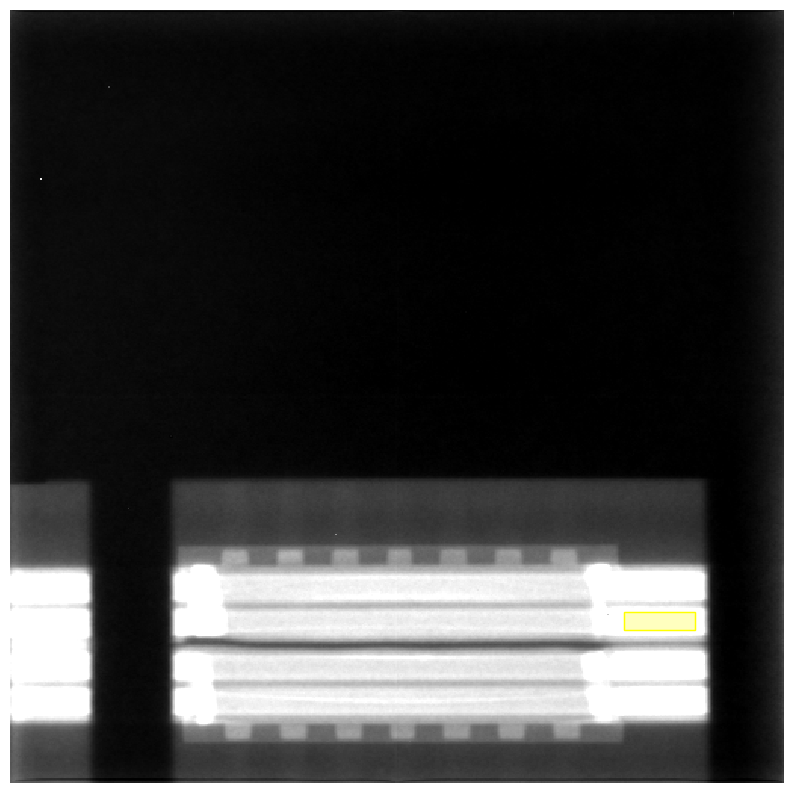

In [17]:
show_img_rois(ref_img_TFC[0], dr = [(nca, 'yellow')])

### Do the remaining TFC correction step for the reference folder

In [18]:
proc_seq = ['TFC_correction_dict']
use_ref = False
list_proc_param = ['ref_img_TFC', 'nca', 'use_ref']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
ref_test_dict = processing_step (ref_test_dict, proc_seq, list_proc_dict)

Processing TFC Correction: 100%|█████████████████| 1/1 [00:00<00:00,  4.95it/s]


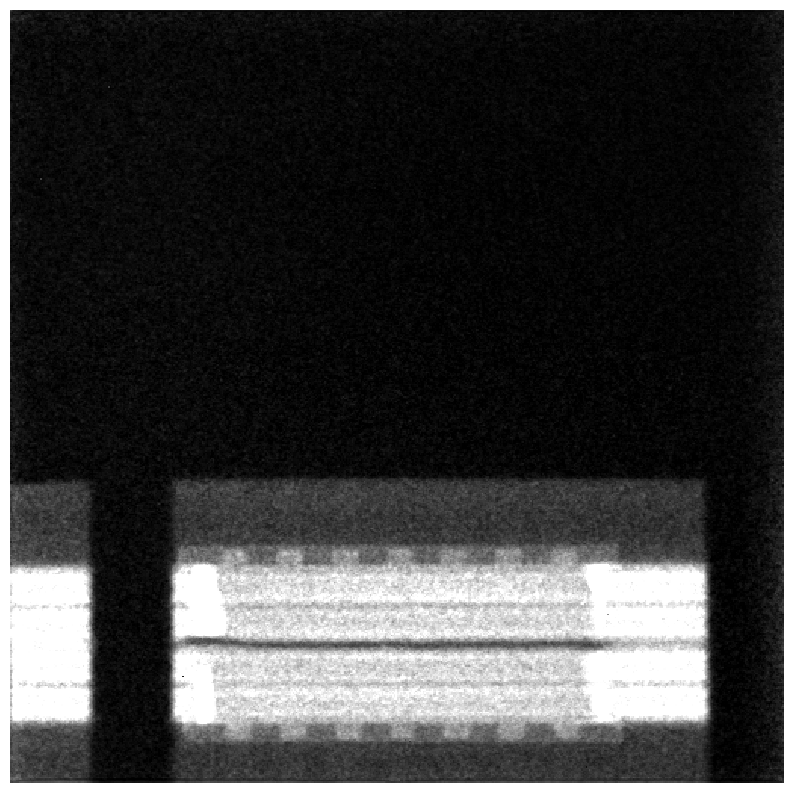

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
EXTEND  =                    T                                                  
TIMESTMP= 'Tue Aug 24 12:02:12 2021'                                            
TIME_DAT=         1629799332.0                                                  
COMMENT User: Ricardo Carreon                                                   
COMMENT SBKG Image created on: 2022-06-20 11:59:30.149666                       
HISTORY Sequence: ['outlier_removal']                                           
HISTORY Sequence: Pulse average. X-axis (acquisitions)                          
HISTORY Process: Scrubbing c

In [19]:
test = ref_test_dict['01_so_ref'][0][30]
show_img(test[0])
test[1]

In [20]:
dst_dir_test = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_new_framweork_results\exp1XX_SA_avg_test"
saving_step (ref_test_dict, dst_dir_test, img_name = 'reference_avg_testing')

Saving images as a single acquisition


Saving Images: 100%|█████████████████████████████| 1/1 [00:21<00:00, 21.18s/it]


#### IF you arrive to thos point, the you are satisfied with the results

## Experiment SA test processing

In [21]:
proc_folder = ['02_sa']
exp_test_dict, weights_DataFrame = testing_mode_step (src_dir, proc_folder = proc_folder, keep_acq_numb= 4)
pre_proc_seq = [outlier_removal, stack_averaging]
pre_proc_param = dict (threshold = 0)
exp_test_dict = pre_processing_step (exp_test_dict, pre_proc_seq, pre_proc_param)

Processing Filetring : 100%|█████████████████████| 4/4 [01:46<00:00, 26.60s/it]


### For this experiment we require to make a registration (displacements correction)

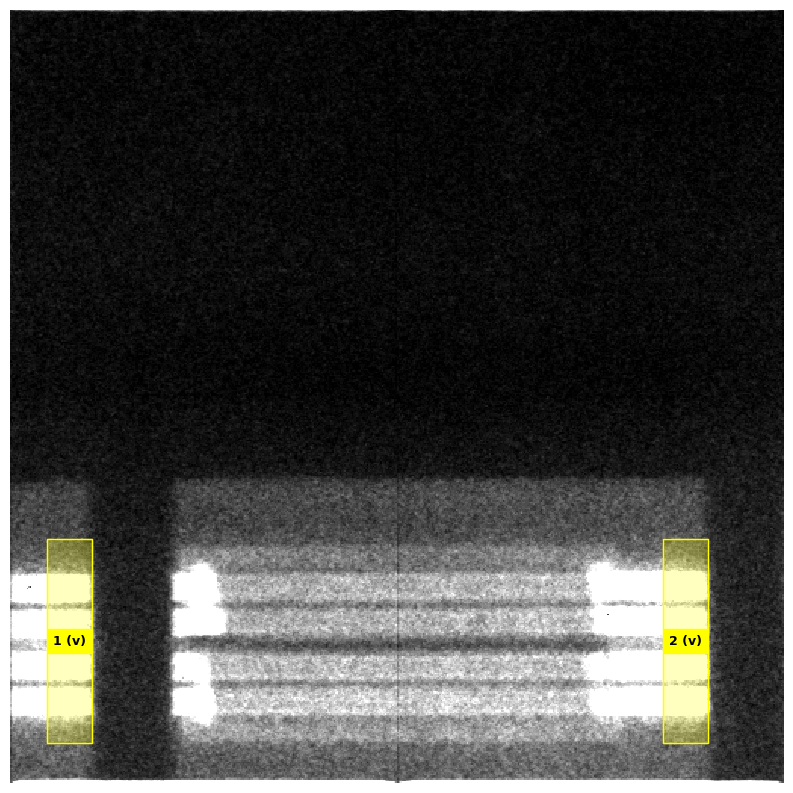

In [24]:
reg_img = get_img(src_dir + '/reg_img_LE_full.fits')
reg_rois_list = [([24, 350, 30, 135], 'v'), ([432, 350, 30, 135], 'v')]

img = exp_test_dict[proc_folder[0]][0][50]
show_img_rois(img[0], dr = [(reg_rois_list, 'yellow')])

### We check if the displacement matrix makes sense, if it does keep the M, if not you can create your own displacement matrix:
This experiment has just a movement in y-axis, for this reason dof is just 'ty' and the displacement is in the first row 3rd column:

disp = float(0.03333333)<br>
M = np.array([[1,0,disp], [0,1,0], [0,0,1]])

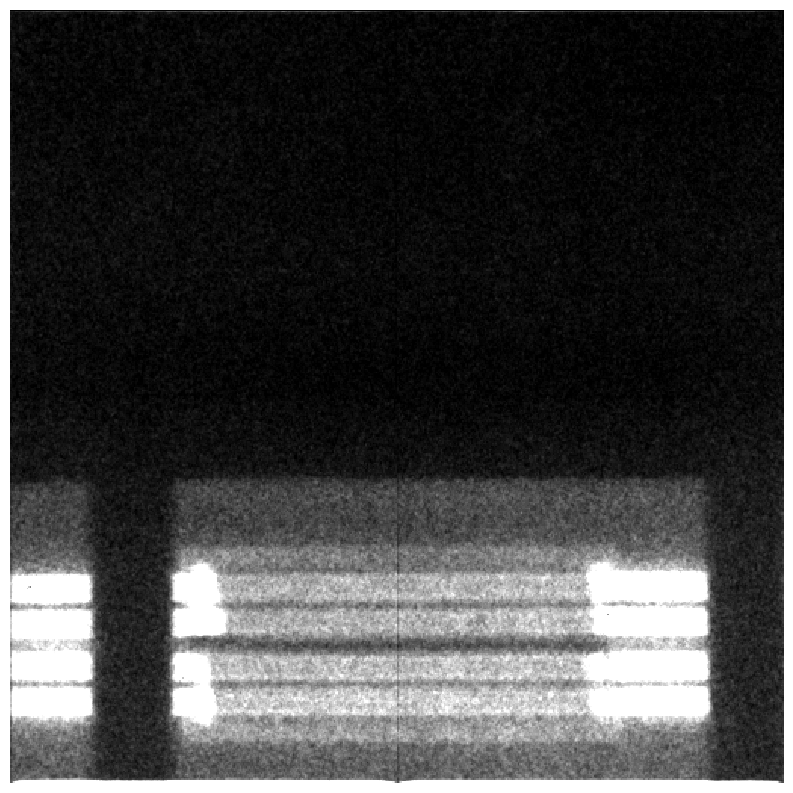

[[ 1.   0.  -0.2]
 [ 0.   1.   0. ]
 [ 0.   0.   1. ]]


In [26]:
img_reg_corr, M = img_registration (img, reg_img, reg_rois_list = reg_rois_list, dof=['ty'])
#show_img(img_reg_corr[0], cmap = 'gray')
print(M)

### This is a different processing than the reference ( added image_registration step). Be aware that you need more paramters 

In [27]:
proc_seq = ['scrubbing_correction_dict', 'image_registration_dict','SBKG_correction_dict', 'TFC_correction_dict']

In [28]:
# %load select_rois(img, list_rois = ['nca'])
nca = [406, 398, 47, 12]

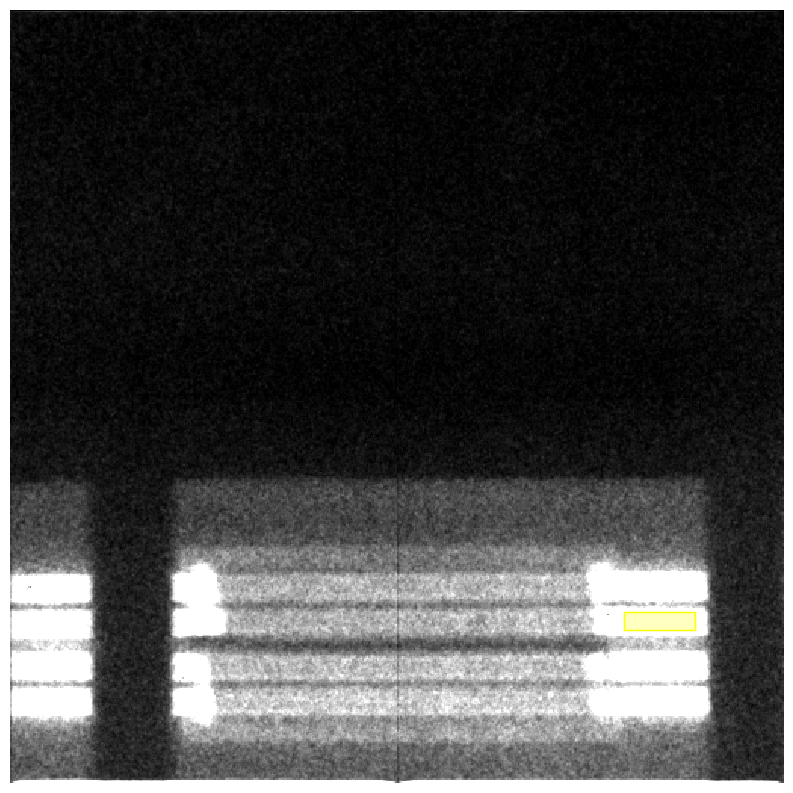

In [29]:
BB_mask = get_img(src_dir + '/bb_mask_full.fits')
use_ref = False
dof = ['ty']
show_img_rois(img_reg_corr[0], dr = [(nca, 'yellow')])

In [30]:
list_proc_param = ['weights_DataFrame', 'reg_img, reg_rois_list', 'dof', 'M', 'BB_mask', 'ref_img_TFC', 'nca', 'use_ref = False']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
exp_test_dict = processing_step (exp_test_dict, proc_seq, list_proc_dict)

Processing TFC Correction: 100%|█████████████████| 1/1 [00:00<00:00,  3.84it/s]


In [31]:
dst_dir_test = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_new_framweork_results\exp1XX_SA_SO_avg_test"
saving_step (exp_test_dict, dst_dir_test, img_name = 'SA_avg_testing')

Saving images as a single acquisition


Saving Images: 100%|█████████████████████████████| 1/1 [00:21<00:00, 21.16s/it]


## Reference images averaged processing

In [32]:
ref_dict, weights_DataFrame = reading_step (src_dir, proc_folder = ref_folder)
pre_proc_seq = [outlier_removal, stack_averaging]
pre_proc_param = dict (threshold = 0)
ref_dict = pre_processing_step (ref_dict, pre_proc_seq, pre_proc_param)

Processing Filetring : 100%|█████████████████████| 6/6 [02:50<00:00, 28.41s/it]


In [33]:
proc_seq = ['scrubbing_correction_dict', 'SBKG_correction_dict']
BB_mask = get_img(src_dir + '/bb_mask_ref_full.fits')
list_proc_param = ['weights_DataFrame', 'BB_mask']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
ref_dict = processing_step (ref_dict, proc_seq, list_proc_dict)

Processing SBKG Correction: 100%|████████████████| 1/1 [00:19<00:00, 19.11s/it]


In [34]:
ref_img_TFC = avg_frames_dict (ref_dict[ref_folder[0]], output_type = 'img')

In [35]:
# %load select_rois(img, list_rois = ['nca'])
nca = [406, 398, 47, 12]

In [36]:
proc_seq = ['TFC_correction_dict']
use_ref = False
list_proc_param = ['ref_img_TFC', 'nca', 'use_ref']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
ref_dict = processing_step (ref_dict, proc_seq, list_proc_dict)

Processing TFC Correction: 100%|█████████████████| 1/1 [00:00<00:00,  4.99it/s]


### Saving Reference images step

In [37]:
saving_step (ref_dict, dst_dir, img_name = 'reference_avg')

Saving images as a single acquisition


Saving Images: 100%|█████████████████████████████| 1/1 [00:22<00:00, 22.08s/it]


## Experiment SA averaged processing

In [38]:
proc_folder = ['02_sa']
exp_dict, weights_DataFrame = reading_step (src_dir, proc_folder = proc_folder)
pre_proc_seq = [outlier_removal, stack_averaging]
pre_proc_param = dict (threshold = 0)
exp_dict = pre_processing_step (exp_dict, pre_proc_seq, pre_proc_param)

Processing Filetring : 100%|█████████████████████| 6/6 [02:46<00:00, 27.70s/it]


In [39]:
proc_seq = ['scrubbing_correction_dict', 'image_registration_dict','SBKG_correction_dict', 'TFC_correction_dict']

In [40]:
# %load select_rois(img, list_rois = ['nca'])
nca = [406, 398, 47, 12]

In [41]:
BB_mask = get_img(src_dir + '/bb_mask_full.fits')
use_ref = False
dof = ['ty']

In [43]:
list_proc_param = ['weights_DataFrame', 'reg_img, reg_rois_list', 'dof', 'M', 'BB_mask', 'ref_img_TFC', 'nca', 'use_ref']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
exp_dict = processing_step (exp_dict, proc_seq, list_proc_dict)

Processing TFC Correction: 100%|█████████████████| 1/1 [00:00<00:00,  4.90it/s]


### Saving experiment images step

In [44]:
saving_step (exp_dict, dst_dir, img_name = 'SA_avg')

Saving images as a single acquisition


Saving Images: 100%|█████████████████████████████| 1/1 [00:21<00:00, 21.17s/it]


## Experiment SA  full processing

### we can apply the same process ad before but now the pre_processing will not contain the averaging step

In [48]:
full_exp_dict, weights_DataFrame = reading_step (src_dir, proc_folder = proc_folder)
pre_proc_seq = [outlier_removal]
pre_proc_param = dict (threshold = 0)
full_exp_dict = pre_processing_step (full_exp_dict, pre_proc_seq, pre_proc_param)

Processing Filetring : 100%|█████████████████████| 6/6 [02:45<00:00, 27.56s/it]


### We can keep the same values as before, we just need to re-run the process... In any case we check if they are the correct ones

In [49]:
proc_seq

['scrubbing_correction_dict',
 'image_registration_dict',
 'SBKG_correction_dict',
 'TFC_correction_dict']

In [54]:
test = [key for key in list_proc_dict.keys()]
test

['weights_DataFrame',
 'reg_img, reg_rois_list',
 'dof',
 'M',
 'BB_mask',
 'ref_img_TFC',
 'nca',
 'use_ref']

In [51]:
full_exp_dict = processing_step (full_exp_dict, proc_seq, list_proc_dict)

Processing TFC Correction: 100%|███████████████| 24/24 [00:04<00:00,  4.93it/s]


### saving experiment images step

In [52]:
dst_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_new_framweork_results\exp1XX_SA_SO"
saving_step (full_exp_dict, dst_dir, img_name = 'SA')

Saving images as a time series of acquisitions


Saving Images: 100%|███████████████████████████| 24/24 [08:58<00:00, 22.42s/it]


## Reference Images full processing

In [55]:
full_ref_dict, weights_DataFrame = reading_step (src_dir, proc_folder = ref_folder)
pre_proc_seq = [outlier_removal]
pre_proc_param = dict (threshold = 0)
full_ref_dict = pre_processing_step (full_ref_dict, pre_proc_seq, pre_proc_param)

Processing Filetring : 100%|█████████████████████| 6/6 [02:40<00:00, 26.73s/it]


In [56]:
proc_seq = ['scrubbing_correction_dict', 'SBKG_correction_dict']
BB_mask = get_img(src_dir + '/bb_mask_ref_full.fits')
list_proc_param = ['weights_DataFrame', 'BB_mask']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
full_ref_dict = processing_step (full_ref_dict, proc_seq, list_proc_dict)

Processing SBKG Correction: 100%|██████████████| 25/25 [08:22<00:00, 20.09s/it]


In [57]:
ref_img_TFC = avg_frames_dict (full_ref_dict[ref_folder[0]], output_type = 'img')

In [58]:
# %load select_rois(img, list_rois = ['nca'])
nca = [406, 398, 47, 12]

In [59]:
proc_seq = ['TFC_correction_dict']
use_ref = False
list_proc_param = ['ref_img_TFC', 'nca', 'use_ref']
list_proc_dict = dict((name,eval(name)) for name in list_proc_param)
full_ref_dict = processing_step (full_ref_dict, proc_seq, list_proc_dict)

Processing TFC Correction: 100%|███████████████| 25/25 [00:05<00:00,  4.82it/s]


In [60]:
dst_dir = r"J:\900 Varia\2021\000_tony_data\03_Processed_step_by_step\00_new_framweork_results\exp1XX_SA_SO"
saving_step (full_ref_dict, dst_dir, img_name = 'SO')

Saving images as a time series of acquisitions


Saving Images: 100%|███████████████████████████| 25/25 [08:43<00:00, 20.96s/it]
